In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
masoudnickparvar_brain_tumor_mri_dataset_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')

print('Data source import complete.')

Data source import complete.


**Import Libraries**

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Input
import tensorflow as tf
import os
import seaborn as sns
import warnings
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

**Suppress Warnings and Define Class Labels**

In [ ]:
# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Define class names
class_names = ['Giloma', 'Meningioma', 'Pituitary', 'No Tumor']

**Load and Analyze Dataset Size**

In [ ]:
# Load and analyze dataset size
train_sizes = [
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training/glioma')),
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training/meningioma')),
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training/pituitary')),
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training/notumor')),
]
test_sizes = [
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Testing/glioma')),
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma')),
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary')),
    len(os.listdir('/kaggle/input/brain-tumor-mri-dataset/Testing/notumor')),
]

train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

**Visualize Dataset Distribution**

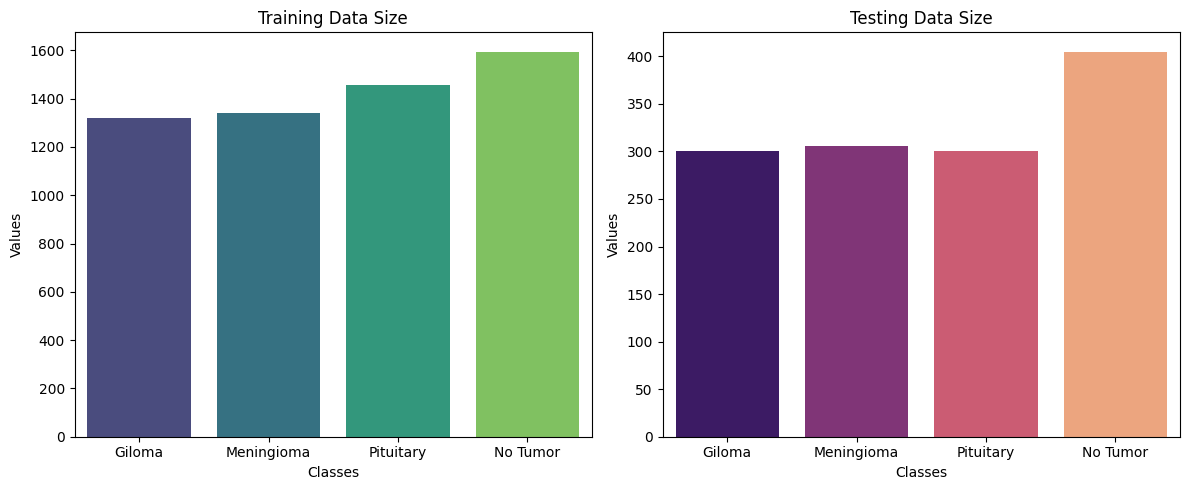

In [ ]:
# Visualize dataset distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=class_names, y=train_sizes, palette="viridis", ax=axes[0])
axes[0].set_title('Training Data Size')
axes[0].set_xlabel('Classes')
axes[0].set_ylabel('Values')

sns.barplot(x=class_names, y=test_sizes, palette="magma", ax=axes[1])
axes[1].set_title('Testing Data Size')
axes[1].set_xlabel('Classes')
axes[1].set_ylabel('Values')

plt.tight_layout()
plt.show()

**Display Sample Images from Dataset**

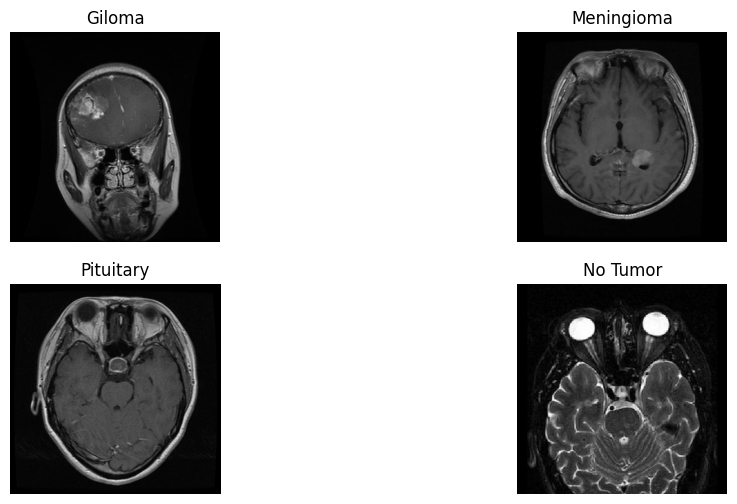

In [ ]:
# Display sample images
fig, (row1, row2) = plt.subplots(2, 2, figsize=(12, 6))
row1[0].imshow(Image.open('/kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0000.jpg'))
row1[0].set_title(class_names[0])
row1[0].set_axis_off()

row1[1].imshow(Image.open('/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-meTr_0002.jpg'))
row1[1].set_title(class_names[1])
row1[1].set_axis_off()

row2[0].imshow(Image.open('/kaggle/input/brain-tumor-mri-dataset/Training/pituitary/Tr-piTr_0001.jpg'))
row2[0].set_title(class_names[2])
row2[0].set_axis_off()

row2[1].imshow(Image.open('/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-noTr_0001.jpg'))
row2[1].set_title(class_names[3])
row2[1].set_axis_off()
plt.show()

**Image Preprocessing with ImageDataGenerator**

In [ ]:
# Preprocess images using ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255  # Normalize images
)
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255  # Normalize images
)

**Load and Prepare Dataset for Training**

In [ ]:
# Load training and testing datasets
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

# Display dataset details
total_training_samples = train_generator.samples
print("Total training samples:", total_training_samples)
class_indices = train_generator.class_indices
print("Class indices:", class_indices)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Total training samples: 5712
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**Build and Compile CNN Model**

In [ ]:
# Build CNN Model
model = Sequential([
    Input(shape=(150, 150, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(4, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     9,470,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,526,916 (36.34 MB)

 Trainable params: 9,526,916 (36.34 MB)

 Non-trainable params: 0 (0.00 B)

**Compile and Train the CNN Model**

In [ ]:
# Compile and train the model
model.compile(optimizer="adam",
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_generator, epochs=50)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 38s 180ms/step - accuracy: 0.6401 - loss: 0.9110
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.8903 - loss: 0.3175
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.9453 - loss: 0.1560
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9711 - loss: 0.0896
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9877 - loss: 0.0374
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9888 - loss: 0.0367
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.9934 - loss: 0.0201
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9927 - loss: 0.0223
Epoch 9/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9991 - loss: 0.0027
Epoch 10/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9998 - loss: 0.0020
Epoch 11/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9997 - loss: 0.0012
Epoch 12/50
179/179 ━━━━━━━━━

**Visualize Training Performance**

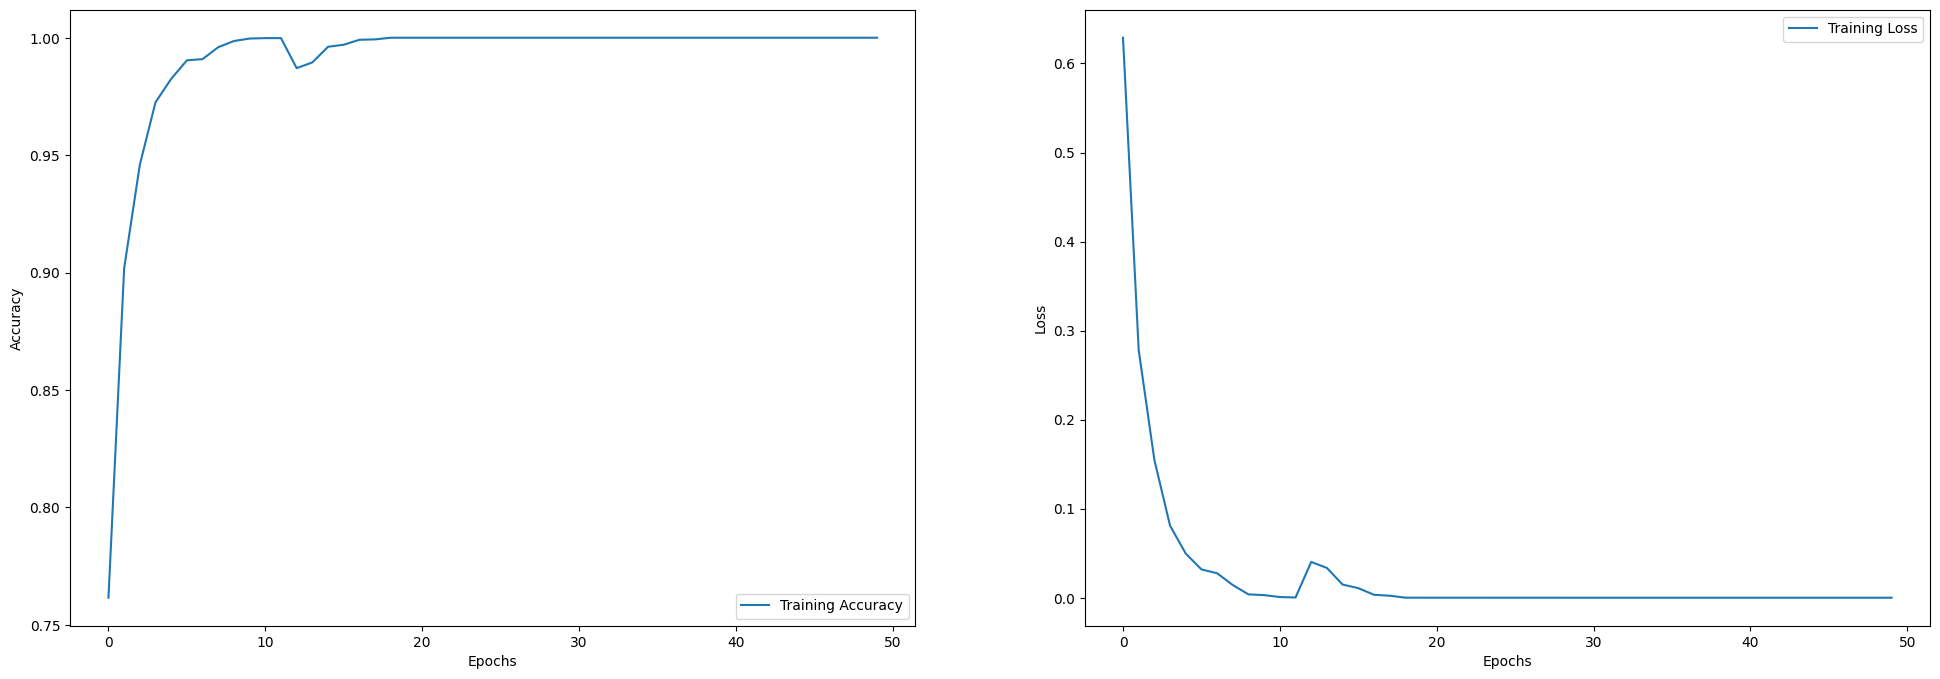

In [ ]:
# Visualize training performance
fig, (row1, row2) = plt.subplots(1, 2, figsize=(24, 8))

sns.lineplot(data=history.history['accuracy'], label='Training Accuracy', ax=row1)
row1.set_xlabel('Epochs')
row1.set_ylabel('Accuracy')
row1.legend()

sns.lineplot(data=history.history['loss'], label='Training Loss', ax=row2)
row2.set_xlabel('Epochs')
row2.set_ylabel('Loss')
row2.legend()

plt.show()

**Evaluate the Model**

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
y_pred = model.predict(test_generator)
predicted_classes = np.argmax(y_pred, axis=1)

# Get class labels
class_labels = list(test_generator.class_indices.keys())
print(classification_report(test_generator.classes, predicted_classes, target_names=class_labels))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 350ms/step - accuracy: 0.9569 - loss: 0.4986
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.95      0.96       300
  meningioma       0.94      0.95      0.95       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.99      1.00      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



**Display Confusion Matrix**

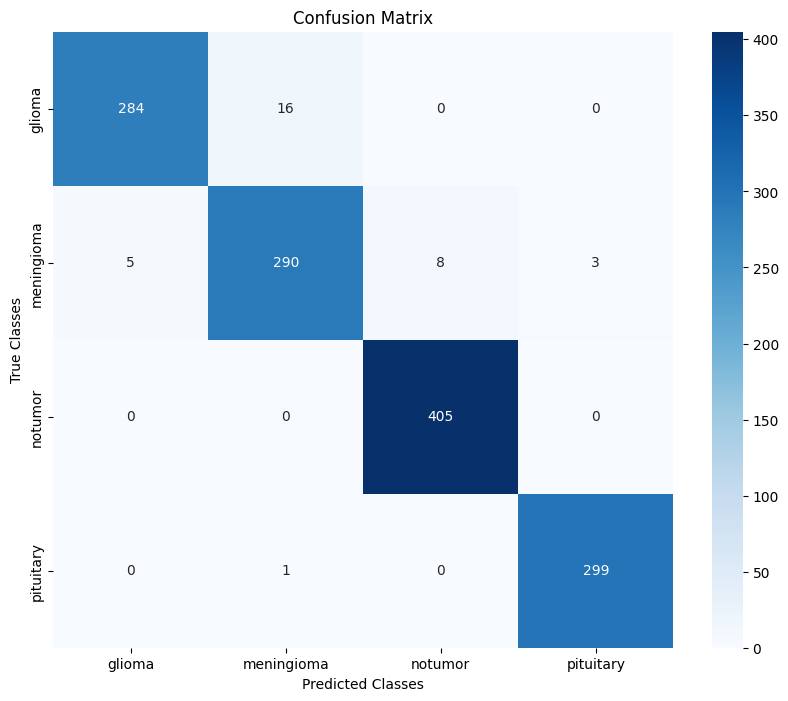

In [ ]:
# Display Confusion Matrix
cm = confusion_matrix(test_generator.classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Classes')
plt.ylabel('True Classes')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout


In [ ]:
resnet_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)
resnet_train = resnet_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
resnet_test = resnet_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=64, class_mode='categorical', shuffle=False)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
resnet_base = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in resnet_base.layers:
    layer.trainable = False

resnet_model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet_history = resnet_model.fit(resnet_train, epochs=50)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 135ms/step - accuracy: 0.7214 - loss: 0.7951
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.8947 - loss: 0.2791
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.9163 - loss: 0.2226
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.9286 - loss: 0.1887
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.9377 - loss: 0.1651
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.9431 - loss: 0.1431
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.9558 - loss: 0.1269
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.9570 - loss: 0.1197
Epoch 9/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.9651 - loss: 0.0949
Epoch 10/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.9688 - loss: 0.0869
Epoch 11/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.9705 - loss: 0.0803
Epoch 12/50
179/179 ━━━━━━━━━━

In [ ]:
vgg_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess)
vgg_train = vgg_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
vgg_test = vgg_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=64, class_mode='categorical', shuffle=False)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in vgg_base.layers:
    layer.trainable = False

vgg_model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg_history = vgg_model.fit(vgg_train, epochs=50)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 71s 311ms/step - accuracy: 0.6478 - loss: 1.4278
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.8797 - loss: 0.3460
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.9096 - loss: 0.2426
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 32s 177ms/step - accuracy: 0.9231 - loss: 0.2094
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.9323 - loss: 0.1704
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.9497 - loss: 0.1408
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.9493 - loss: 0.1229
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 162ms/step - accuracy: 0.9565 - loss: 0.1162
Epoch 9/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 162ms/step - accuracy: 0.9611 - loss: 0.1078
Epoch 10/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 162ms/step - accuracy: 0.9657 - loss: 0.0881
Epoch 11/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.9737 - loss: 0.0713
Epoch 12/50
179/179

In [ ]:
# Save the entire model
vgg_model.save("brain_vgg16.h5")

In [ ]:
!pip install keras2onnx
!pip install onnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.3/96.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 108.8 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=6d3049da744fb552e8fadd442e614266401d81781ed20d9f84bd5850d91d2701
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [ ]:
import keras2onnx
from keras.models import load_model
import onnx

# Load your trained Keras model
model = load_model("brain_vgg16.h5")

# Convert to ONNX format
onnx_model = keras2onnx.convert_keras(model, model.name)

# Save the ONNX model
onnx.save_model(onnx_model, "brain_vgg16.onnx")

print("Model converted and saved as brain_vgg16.onnx")

AttributeError: module 'tensorflow.python.keras' has no attribute 'applications'

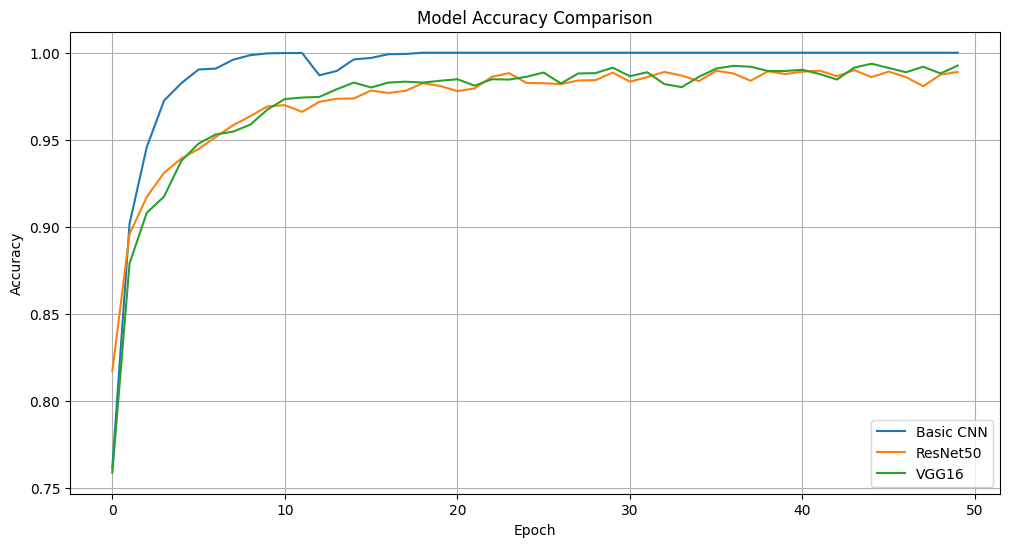

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Basic CNN')
plt.plot(resnet_history.history['accuracy'], label='ResNet50')
plt.plot(vgg_history.history['accuracy'], label='VGG16')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 598ms/step


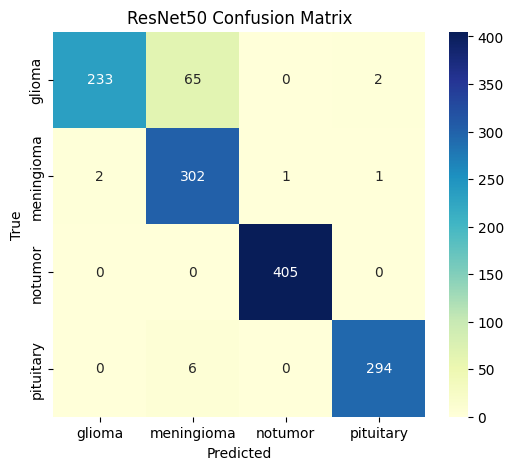

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 40s 905ms/step


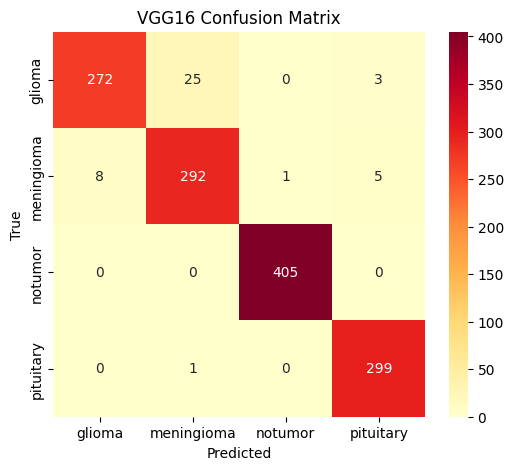

In [ ]:
# RESNET50
resnet_pred = np.argmax(resnet_model.predict(resnet_test), axis=1)
cm_resnet = confusion_matrix(resnet_test.classes, resnet_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_labels, yticklabels=class_labels)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# VGG16
vgg_pred = np.argmax(vgg_model.predict(vgg_test), axis=1)
cm_vgg = confusion_matrix(vgg_test.classes, vgg_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='YlOrRd', xticklabels=class_labels, yticklabels=class_labels)
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
import keras2onnx
from keras.models import load_model
import onnx

# Load your existing .h5 model
model = load_model("brain_vgg16.h5")

# Convert to ONNX
onnx_model = keras2onnx.convert_keras(model, model.name)

# Save the ONNX model
onnx.save_model(onnx_model, "brain_vgg16.onnx")

print("Model converted and saved as brain_vgg16.onnx")

AttributeError: module 'tensorflow.python.keras' has no attribute 'applications'

In [ ]:
!pip install keras2onnx onnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.3/96.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 9.0 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=0cd7ccff63e3d38a0cfd37345fb36615e7b58f22244c6b150891849772875485
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [ ]:
!pip install tf2onnx

INFO: pip is looking at multiple versions of onnx to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 17.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: onnx
    Found existing installation: onnx 1.18.0
    Uninstalling onnx-1.18.0:
      Successfully uninstalled onnx-1.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
ydf 0.12.0 requires prot

In [ ]:
import tensorflow as tf
import tf2onnx

# Load your trained Keras model
model = tf.keras.models.load_model("brain_vgg16.h5")

# Define a tf.function with explicit input and output signatures
@tf.function
def predict_fn(x):
    return model(x)

# Convert the tf.function to ONNX format
input_signature = [tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name="input_1")]
onnx_model, _ = tf2onnx.convert.from_function(
    predict_fn,
    input_signature=input_signature,
    opset=13
)

# Save the ONNX model
with open("brain_vgg16.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Model converted and saved as brain_vgg16.onnx")

ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7b58bdcb40e0>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.


Model converted and saved as brain_vgg16.onnx
